## **Contexto da Análise**

A rotatividade de funcionários representa um custo significativo para as empresas, tanto financeiro quanto operacional. Este projeto utiliza uma base de dados de Recursos Humanos com informações demográficas, profissionais e organizacionais dos colaboradores, com o objetivo de investigar os fatores associados à saída de funcionários da empresa. A partir de uma análise exploratória e relacional dos dados, busca-se identificar padrões e variáveis que possam explicar ou estar relacionadas ao desligamento, fornecendo insights que apoiem decisões de gestão de pessoas e estratégias de retenção.

### 📌 **Perguntas Centrais**

- Existe um perfil típico de funcionário com maior risco de desligamento?
- Quais fatores mais diferenciam os funcionários que deixaram a empresa daqueles que permaneceram?

#### 📊 **Subanálises**
1. Tempo e Progressão de Carreira
2. Liderança e Gestão
3. Remuneração e Reconhecimento
4. Qualidade de Vida e Carga de Trabalho
5. Satisfação e Desempenho
6. Características Demográficas

### Análise Exploratória

In [42]:
# notebook setup
# sys para interagir com o interpretador python
import sys
# pathlib facilita o trabalho com caminhos de arquivos e diretórios
from pathlib import Path

# adicionando a pasta raiz do projeto ao pythonpath
# permite a importação de módulos da pasta src
root_dir = Path().resolve().parent
sys.path.append(str(root_dir))

In [43]:
# imports 
# pandas para manipulação e análise de dados
import pandas as pd
# matplotlib e seaborn para visualização de dados estatísticos
import matplotlib.pyplot as plt
import seaborn as sns
# funções de carregamento de dados e o caminho do dataset
from src.utils import load_data
from src.paths import processed_data_path

In [44]:
# carregando a base de dados tratada
# (dados já padronizados no notebook de limpeza)
df = load_data(processed_data_path)
# validação rápida do carregamento
df.head()

,saiu_da_empresa,idade,frequencia_de_viagens,distancia_do_trabalho,formacao,e-sat,genero,estado_civil,salario,quantidade_de_empresas_trabalhadas,faz_hora_extra,percentual_de_aumento,quantidade_de_acoes_da_empresa,tempo_de_carreira,horas_de_treinamento,equilibrio_de_vida,tempo_de_empresa,anos_no_mesmo_cargo,anos_desde_a_ultima_promocao,anos_com_o_mesmo_chefe
0,Sim,41,Viaja raramente,1,Ensino Técnico,Médio,M,Solteiro,5993,8,Sim,11,0,8,0,Ruim,6,4,0,5
1,Não,49,Viaja frequentemente,8,Ensino Médio,Alto,H,Casado,5130,1,Não,23,1,10,3,Muito bom,10,7,1,7
2,Sim,37,Viaja raramente,2,Ensino Técnico,Muito Alto,H,Solteiro,2090,6,Sim,15,0,7,3,Muito bom,0,0,0,0
3,Não,33,Viaja frequentemente,3,Mestrado,Muito Alto,M,Casado,2909,1,Sim,11,0,8,3,Muito bom,8,7,3,0
4,Não,27,Viaja raramente,2,Ensino Médio,Baixo,H,Casado,3468,9,Não,12,1,6,3,Muito bom,2,2,2,2


In [45]:
df.shape

(1470, 20)

In [46]:
df.describe().round(1)

,idade,distancia_do_trabalho,salario,quantidade_de_empresas_trabalhadas,percentual_de_aumento,quantidade_de_acoes_da_empresa,tempo_de_carreira,horas_de_treinamento,tempo_de_empresa,anos_no_mesmo_cargo,anos_desde_a_ultima_promocao,anos_com_o_mesmo_chefe
count,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0
mean,36.9,9.2,6502.9,2.7,15.2,0.8,11.3,2.8,7.0,4.2,2.2,4.1
std,9.1,8.1,4708.0,2.5,3.7,0.9,7.8,1.3,6.1,3.6,3.2,3.6
min,18.0,1.0,1009.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,30.0,2.0,2911.0,1.0,12.0,0.0,6.0,2.0,3.0,2.0,0.0,2.0
50%,36.0,7.0,4919.0,2.0,14.0,1.0,10.0,3.0,5.0,3.0,1.0,3.0
75%,43.0,14.0,8379.0,4.0,18.0,1.0,15.0,3.0,9.0,7.0,3.0,7.0
max,60.0,29.0,19999.0,9.0,25.0,3.0,40.0,6.0,40.0,18.0,15.0,17.0


In [47]:
df.describe(include='object')

,saiu_da_empresa,frequencia_de_viagens,formacao,e-sat,genero,estado_civil,faz_hora_extra,equilibrio_de_vida
count,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,5,4,2,3,2,4
top,Não,Viaja raramente,Ensino Superior,Alto,H,Casado,Não,Muito bom
freq,1233,1043,572,453,882,673,1054,893


In [48]:
# quantidade de funcionários que saíram da empresa
df_total = df['saiu_da_empresa'].value_counts(())
df_total

saiu_da_empresa
Não    1233
Sim     237
Name: count, dtype: int64

In [49]:
df['status_funcionarios'] = df['saiu_da_empresa'].map({
    'Sim': 'Saíram',
    'Não': 'Permaneceram'
})

In [50]:
# distribuição da variável alvo
contagem = df['saiu_da_empresa'].value_counts()
taxa = df['saiu_da_empresa'].value_counts(normalize=True) * 100

resumo = pd.DataFrame({'quantidade': contagem, 'percentual (%)': taxa.round(1)})
print(resumo)

                 quantidade  percentual (%)
saiu_da_empresa                            
Não                    1233            83.9
Sim                     237            16.1


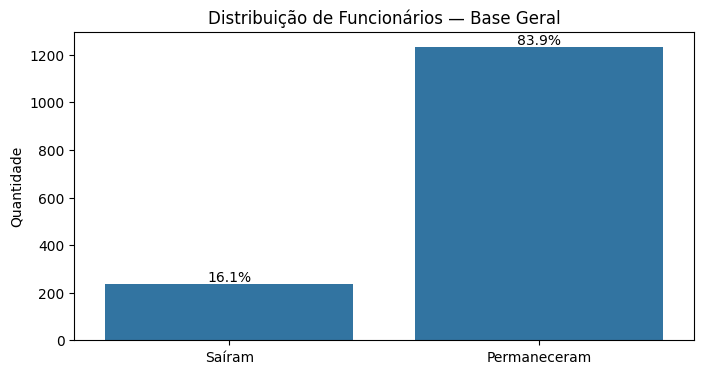

In [51]:
# visualização do desbalanceamento
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='status_funcionarios')
plt.title('Distribuição de Funcionários — Base Geral')
plt.xlabel('')
plt.ylabel('Quantidade')

# anotando os percentuais nas barras
for p in plt.gca().patches:
    pct = f"{100 * p.get_height() / len(df):.1f}%"
    plt.gca().annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height() + 10), ha='center')

plt.show()

**Observação sobre o desbalanceamento da base**

A base apresenta uma proporção significativamente diferente entre os dois grupos:
cerca de 84% dos funcionários permaneceram na empresa, enquanto apenas 16% saíram.

Essa diferença de tamanho entre os grupos é um fator importante a considerar na
interpretação dos gráficos ao longo desta análise. Gráficos de contagem absoluta
tendem a ser visualmente dominados pelo grupo majoritário (permaneceram), o que
pode mascarar padrões relevantes no grupo minoritário (saíram).

Por esse motivo, sempre que possível, as análises serão complementadas com o
cálculo da **taxa de desligamento** — a proporção de funcionários que
saíram dentro de cada subgrupo — permitindo comparações mais precisas.

### 🔹Tempo e Progressão de Carreira

 - O tempo no mesmo cargo está associado a maiores taxas de desligamento?

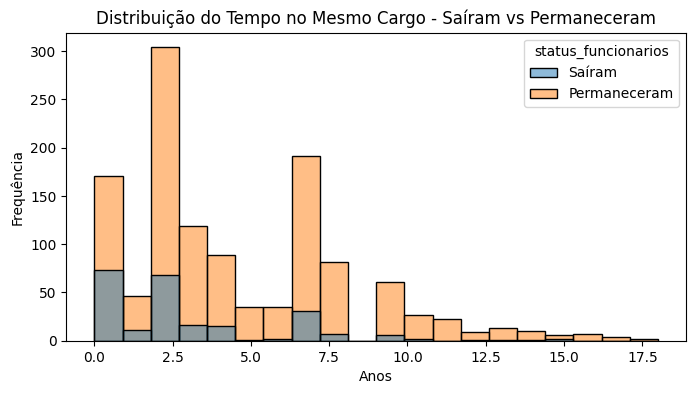

In [52]:
# representação gráfica da distribuição de tempo no mesmo cargo 
plt.figure(figsize=(8,4))
sns.histplot(
  data=df,
  x='anos_no_mesmo_cargo',
  hue='status_funcionarios',
  bins=20
)
plt.title("Distribuição do Tempo no Mesmo Cargo - Saíram vs Permaneceram")
plt.xlabel("Anos")
plt.ylabel("Frequência")
plt.show()

**Leitura do gráfico**

Observa-se maior concentração de desligamentos nos primeiros anos (0 a 2 anos). No entanto, os dois grupos se comportam de forma semelhante nesse mesmo intervalo, indicando que a saída nesse período pode estar mais ligada a adaptação inicial do que ao tempo em si.

- Qual é o impacto do tempo desde a última promoção na rotatividade de funcionários?

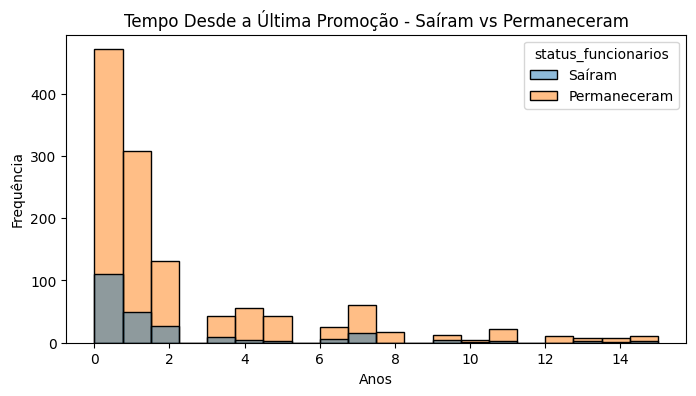

In [53]:
# representação gráfica da distribuição de tempo desde a última promoção
plt.figure(figsize=(8,4))
sns.histplot(
  data=df,
  x='anos_desde_a_ultima_promocao',
  hue='status_funcionarios',
  bins=20
)
plt.title("Tempo Desde a Última Promoção - Saíram vs Permaneceram")
plt.xlabel("Anos")
plt.ylabel("Frequência")
plt.show()

**Leitura do gráfico**

À medida que o tempo desde a última promoção aumenta, observa-se uma redução gradual na proporção de funcionários que permanecem na empresa, indicando maior probabilidade de desligamento em períodos prolongados sem progressão na carreira.

### 🔹Liderança e Gestão

- Funcionários que permanecem por mais tempo com o mesmo gestor tendem a se desligar mais da empresa?

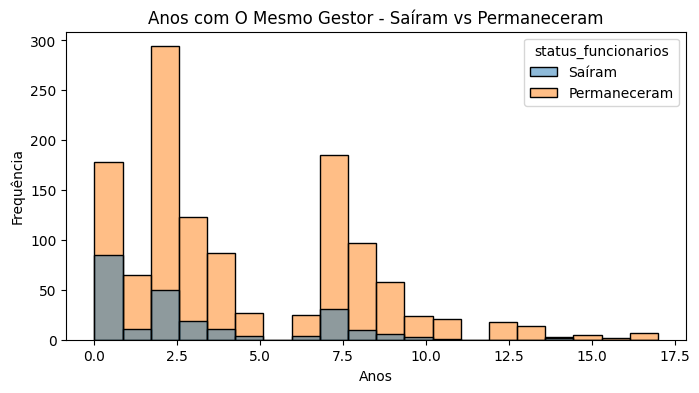

In [54]:
# representação gráfica da distribuição do tempo com o mesmo gestor
plt.figure(figsize=(8,4))
sns.histplot(
  data=df,
  x='anos_com_o_mesmo_chefe',
  hue='status_funcionarios',
  bins=20
)
plt.title("Anos com O Mesmo Gestor - Saíram vs Permaneceram")
plt.xlabel("Anos")
plt.ylabel("Frequência")
plt.show()


**Leitura do gráfico**

A distribuição do tempo com o mesmo gestor é semelhante entre funcionários que saíram e os que permaneceram. Embora desligamentos pontuais ocorram em períodos mais longos de permanência com o mesmo gestor, não se observa um padrão claro que indique maior probabilidade de saída associada exclusivamente a esse fator.

- A combinação de longo tempo no mesmo cargo e com o mesmo gestor influencia a rotatividade?

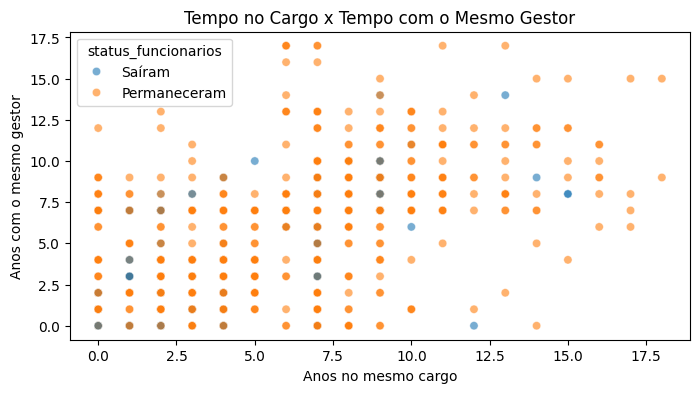

In [55]:
# gráfico de dispersão para analisar duas variáveis ao mesmo tempo
plt.figure(figsize=(8,4))

sns.scatterplot(
    data=df,
    x='anos_no_mesmo_cargo',
    y='anos_com_o_mesmo_chefe',
    hue='status_funcionarios',
    alpha=0.6
)

plt.title("Tempo no Cargo x Tempo com o Mesmo Gestor")
plt.xlabel("Anos no mesmo cargo")
plt.ylabel("Anos com o mesmo gestor")
plt.show()


**Leitura do gráfico**

A análise conjunta do tempo no mesmo cargo e do tempo com o mesmo gestor não evidencia um padrão claro de concentração de desligamentos. Os desligamentos aparecem distribuídos ao longo do gráfico, sugerindo que a combinação não exerce influência significativa sobre a rotatividade.

### 🔹Perfil Profissional

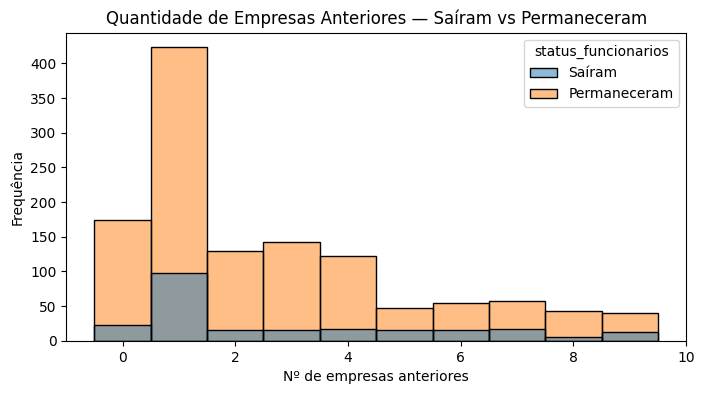

In [56]:
# quantidade de empresas trabalhadas anteriormente
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df,
    x='quantidade_de_empresas_trabalhadas',
    hue='status_funcionarios',
    bins=10,
    discrete=True
)
plt.title('Quantidade de Empresas Anteriores — Saíram vs Permaneceram')
plt.xlabel('Nº de empresas anteriores')
plt.ylabel('Frequência')
plt.show()

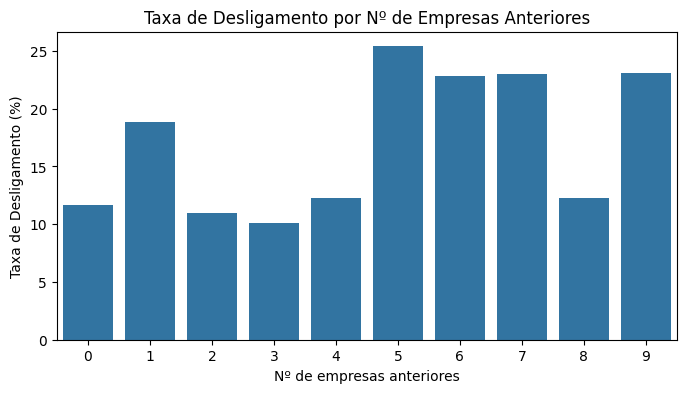

In [57]:
# taxa de desligamento por número de empresas anteriores
taxa_empresas = (
    df
    .groupby('quantidade_de_empresas_trabalhadas')['saiu_da_empresa']
    .apply(lambda x: (x == 'Sim').mean())
    .reset_index(name='taxa_desligamento')
)
taxa_empresas['taxa_desligamento'] *= 100

plt.figure(figsize=(8, 4))
sns.barplot(data=taxa_empresas, x='quantidade_de_empresas_trabalhadas', y='taxa_desligamento')
plt.title('Taxa de Desligamento por Nº de Empresas Anteriores')
plt.xlabel('Nº de empresas anteriores')
plt.ylabel('Taxa de Desligamento (%)')
plt.show()

**Leitura dos gráficos**

A análise da quantidade de empresas anteriores não revela uma tendência clara.
Funcionários que trabalharam em 5, 6, 7 e 9 empresas anteriores apresentam as maiores
taxas de desligamento (23–25%), enquanto aqueles com 2, 3 e 4 empresas anteriores
mostram taxas mais baixas (10–13%).

A hipótese de que maior histórico de trocas está associado a maior
propensão à saída se sustenta parcialmente, mas não de forma consistente ao longo
de todos os grupos.

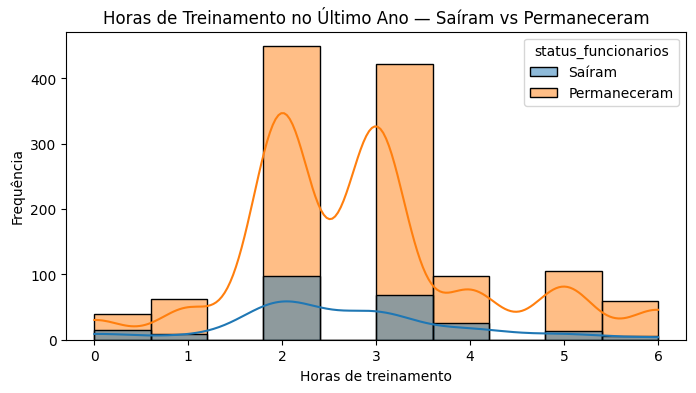

In [58]:
# horas de treinamento
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df,
    x='horas_de_treinamento',
    hue='status_funcionarios',
    bins=10,
    kde=True
)
plt.title('Horas de Treinamento no Último Ano — Saíram vs Permaneceram')
plt.xlabel('Horas de treinamento')
plt.ylabel('Frequência')
plt.show()

**Leitura do gráfico**

A distribuição de horas de treinamento é semelhante entre funcionários que saíram e
os que permaneceram, com maior concentração entre 2 e 3 horas para ambos os grupos.
Não se observa um padrão claro que indique associação entre menor investimento em
treinamento e maior rotatividade.

### 🔹Remuneração e Reconhecimento

- Menores percentuais de aumento salarial estão associados a maiores taxas de desligamento?

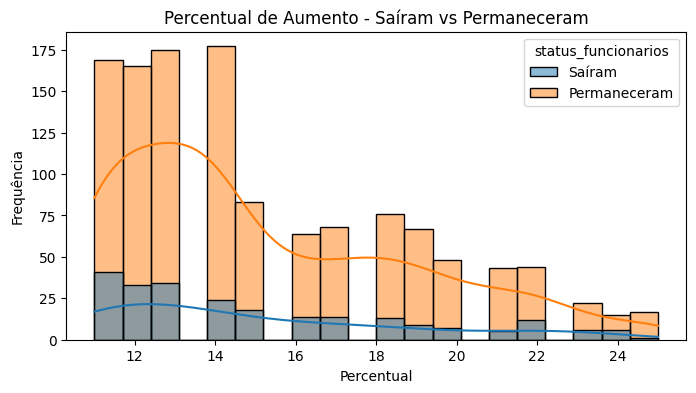

In [59]:
# representação gráfica 
plt.figure(figsize=(8,4))
sns.histplot(
  data=df,
  x='percentual_de_aumento',
  hue='status_funcionarios',
  bins=20,
  kde=True
)
plt.title("Percentual de Aumento - Saíram vs Permaneceram")
plt.xlabel("Percentual")
plt.ylabel("Frequência")
plt.show()

**Leitura do gráfico**

A comparação entre as distribuições indica que os desligamentos estão relativamente mais concentrados nas faixas de menor percentual de aumento salarial. À medida que o percentual de aumento cresce, observa-se uma redução da presença relativa de funcionários desligados, sugerindo uma associação entre aumentos salariais mais baixos e maior propensão à saída da empresa.

- Existe associação entre o nível salarial e a taxa de desligamento dos funcionários?

C:\Users\José Luiz Jr\AppData\Local\Temp\ipykernel_48888\3009199916.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('faixa_salarial')['saiu_da_empresa']


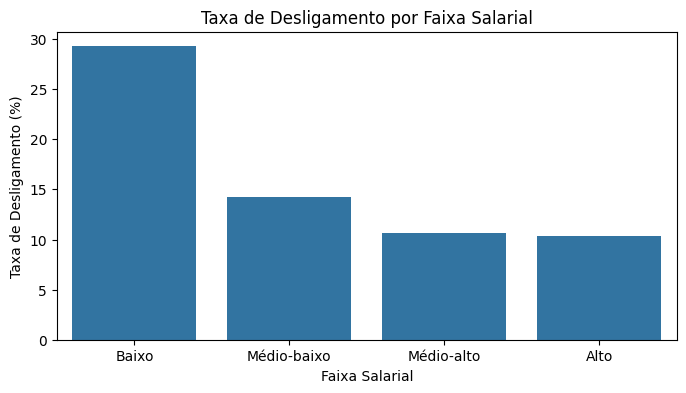

In [76]:
# criando faixas salariais
df['faixa_salarial'] = pd.qcut(
    df['salario'],
    q=4,
    labels=['Baixo', 'Médio-baixo', 'Médio-alto', 'Alto']
)

# cálculo da taxa de desligamento por faixa salarial
taxa_desligamento = (
    df
    .groupby('faixa_salarial')['saiu_da_empresa']
    .apply(lambda x: (x == 'Sim').mean())
    .reset_index(name='taxa_desligamento')
)

taxa_desligamento['taxa_desligamento'] *= 100

# gráfico
plt.figure(figsize=(8,4))
sns.barplot(
    data=taxa_desligamento,
    x='faixa_salarial',
    y='taxa_desligamento'
)
plt.title('Taxa de Desligamento por Faixa Salarial')
plt.xlabel('Faixa Salarial')
plt.ylabel('Taxa de Desligamento (%)')
plt.savefig('../assets/taxa_salario.png', bbox_inches='tight', dpi=150)
plt.show()


**Leitura do gráfico**

Observa-se que as faixas salariais mais baixas apresentam maior taxa de desligamento, indicando que salários menores podem estar associados a um maior risco de saída da empresa.

### 🔹Qualidade de Vida e Carga de Trabalho

- A realização frequente de horas extras está relacionada a maiores índices de desligamento?

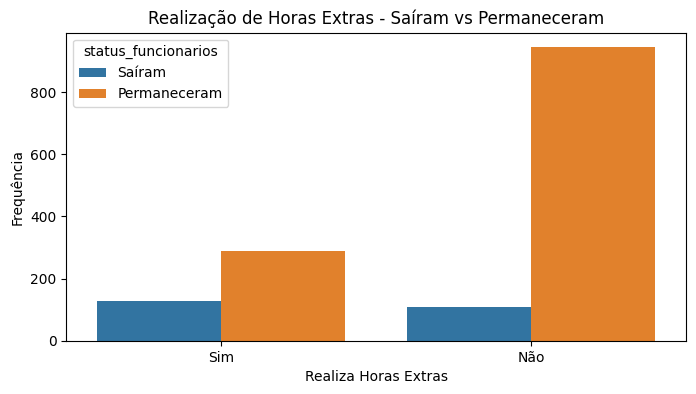

In [61]:
# comparação da realização de horas extras entre funcionários que saíram e os que permaneceram na empresa
plt.figure(figsize=(8,4))
sns.countplot(
  data=df,
  x='faz_hora_extra',
  hue='status_funcionarios'
)
plt.title('Realização de Horas Extras - Saíram vs Permaneceram')
plt.xlabel('Realiza Horas Extras')
plt.ylabel('Frequência')
plt.show()

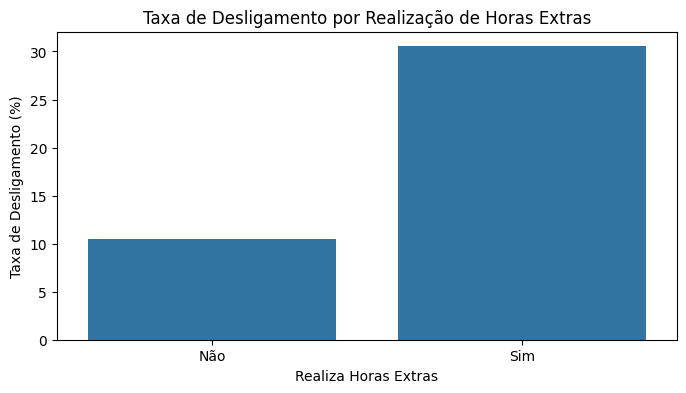

In [77]:
# cálculo da porcentagem de funcionários que saíram em cada grupo
taxa_desligamento = (
    df
    .groupby('faz_hora_extra')['saiu_da_empresa']
    .apply(lambda x: (x == 'Sim').mean())
    .reset_index()
)

taxa_desligamento['taxa_desligamento'] = taxa_desligamento['saiu_da_empresa'] * 100

# gráfico da taxa de desligamento por horas extras
plt.figure(figsize=(8,4))
sns.barplot(
    data=taxa_desligamento,
    x='faz_hora_extra',
    y='taxa_desligamento'
)
plt.title('Taxa de Desligamento por Realização de Horas Extras')
plt.xlabel('Realiza Horas Extras')
plt.ylabel('Taxa de Desligamento (%)')
plt.savefig('../assets/taxa_horas.png', bbox_inches='tight', dpi=150)
plt.show()

**Leitura do Gráfico**

A análise conjunta dos gráficos de frequência e de taxa de desligamento indica que funcionários que realizam horas extras apresentam uma probabilidade significativamente maior de desligamento em comparação aos que não realizam. Embora esse grupo represente uma parcela menor da força de trabalho, sua taxa de rotatividade é aproximadamente três vezes superior, sugerindo que a realização frequente de horas extras pode estar associada a sobrecarga de trabalho e maior propensão à saída da empresa.

- Fatores logísticos, como distância até o trabalho e viagens frequentes, influenciam a saída dos funcionários?

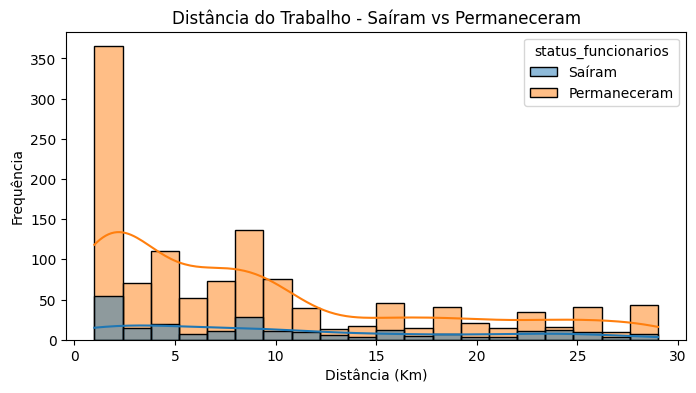

In [63]:
# distância do trabalho
# gráfico da distribuição da distância
plt.figure(figsize=(8,4))
sns.histplot(
  data=df,
  x='distancia_do_trabalho',
  hue='status_funcionarios',
  bins=20,
  kde=True
)
plt.title('Distância do Trabalho - Saíram vs Permaneceram')
plt.xlabel('Distância (Km)')
plt.ylabel('Frequência')
plt.show()

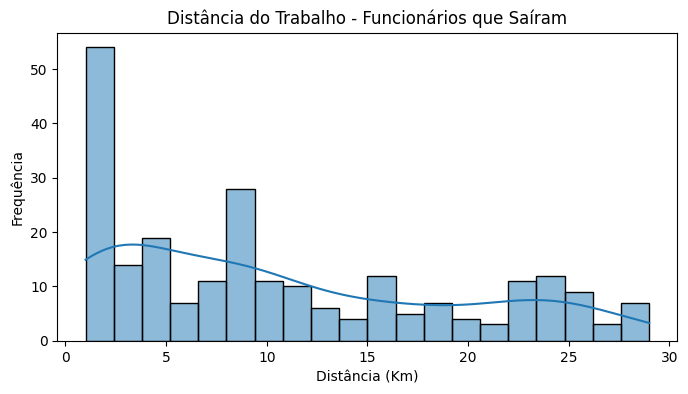

In [64]:
# representação gráfica da distribuição da distância entre os funcionários que saíram
plt.figure(figsize=(8,4))
sns.histplot(
  df[df['saiu_da_empresa'] == 'Sim']['distancia_do_trabalho'], 
  bins=20, 
  kde=True
)
plt.title('Distância do Trabalho - Funcionários que Saíram')
plt.xlabel('Distância (Km)')
plt.ylabel('Frequência')
plt.show()

**Leitura do gráfico**

O gráfico comparativo entre funcionários que saíram e permaneceram mostra que desligamentos ocorrem em praticamente todas as faixas de distância. A maior concentração de funcionários — tanto desligados quanto ativos — encontra-se nas distâncias mais curtas, o que é esperado dado o perfil geral da base. Em conclusão, a distância, isoladamente, não se mostra um fator determinante para o desligamento, embora possa contribuir de forma indireta em casos específicos.

In [65]:
# frequência de viagens
# cálculo da distribuição dos funcionários quanto à frequência de viagens
df_freq_todos = pd.DataFrame(df['frequencia_de_viagens'].value_counts())

df_freq_todos.columns = ["frequencia"]
total = df_freq_todos['frequencia'].sum()
df_freq_todos['freq_relativa'] = (df_freq_todos['frequencia'] / total).round(2)
df_freq_todos['freq_acumulada'] = df_freq_todos['freq_relativa'].cumsum().round(2)
print('Cálculo de Frequência')
df_freq_todos

Cálculo de Frequência


,frequencia,freq_relativa,freq_acumulada
frequencia_de_viagens,,,
Viaja raramente,1043,0.71,0.71
Viaja frequentemente,277,0.19,0.90
Não viaja,150,0.10,1.00


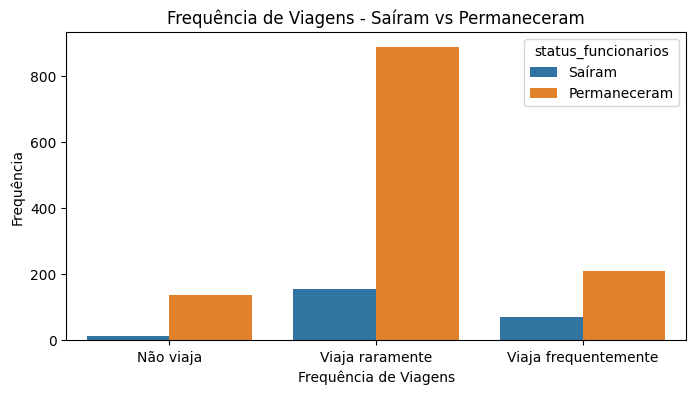

In [66]:
# comparação da frequência de viagens entre funcionários que saíram e os que permaneceram na empresa
plt.figure(figsize=(8,4))
order = ['Não viaja', 'Viaja raramente', 'Viaja frequentemente']
sns.countplot(
  data=df, 
  x='frequencia_de_viagens', 
  hue='status_funcionarios',
  order=order
)
plt.title('Frequência de Viagens - Saíram vs Permaneceram')
plt.xlabel('Frequência de Viagens')
plt.ylabel('Frequência')
plt.show()

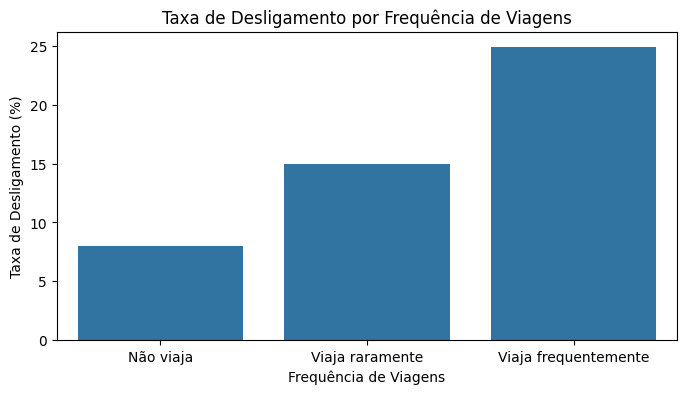

In [79]:
# cálculo da porcentagem de funcionários que saíram em cada grupo
taxa_desligamento = (
    df
    .groupby('frequencia_de_viagens')['saiu_da_empresa']
    .apply(lambda x: (x == 'Sim').mean())
    .reset_index()
)

taxa_desligamento['taxa_desligamento'] = taxa_desligamento['saiu_da_empresa'] * 100

# gráfico da taxa de desligamento por frequência de viagens
plt.figure(figsize=(8,4))
order = ['Não viaja', 'Viaja raramente', 'Viaja frequentemente']
sns.barplot(
    data=taxa_desligamento,
    x='frequencia_de_viagens',
    y='taxa_desligamento',
    order=order
)
plt.title('Taxa de Desligamento por Frequência de Viagens')
plt.xlabel('Frequência de Viagens')
plt.ylabel('Taxa de Desligamento (%)')
plt.savefig('../assets/taxa_viagens.png', bbox_inches='tight', dpi=150)
plt.show()

**Leitura do gráfico**

O gráfico de taxa de desligamento por frequência de viagens revela diferenças claras entre os grupos:

- Funcionários que viajam frequentemente apresentam a maior taxa de desligamento (≈25%)
- Funcionários que viajam raramente apresentam taxa intermediária (≈15%)
- Funcionários que não viajam apresentam a menor taxa de desligamento (≈8%)

Esse padrão indica uma relação direta entre aumento da frequência de viagens e maior probabilidade de saída, sugerindo que deslocamentos frequentes podem impactar negativamente a permanência dos funcionários.

**Conclusão integrada**

Analisando os dois fatores de forma conjunta, observa-se que fatores logísticos não impactam igualmente a rotatividade. Enquanto a distância até o trabalho não apresenta uma associação clara com o desligamento, a frequência de viagens mostra-se fortemente relacionada a maiores taxas de saída, especialmente entre funcionários que viajam com maior regularidade.

### 🔹Satisfação e Desempenho

- Existe relação entre o nível de satisfação dos funcionários (e-sat) e a probabilidade de saída da empresa?

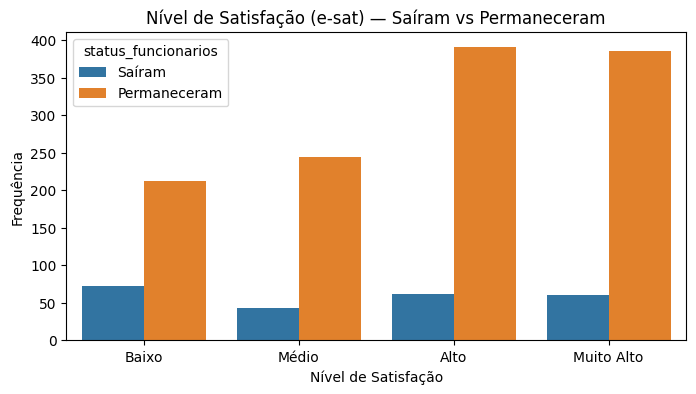

In [68]:
# gráfico saíram vs permaneceram
plt.figure(figsize=(8,4))
order = ['Baixo', 'Médio', 'Alto', 'Muito Alto']
sns.countplot(
    data=df,
    x='e-sat',
    hue='status_funcionarios',
    order=order
)
plt.title('Nível de Satisfação (e-sat) — Saíram vs Permaneceram')
plt.xlabel('Nível de Satisfação')
plt.ylabel('Frequência')
plt.show()


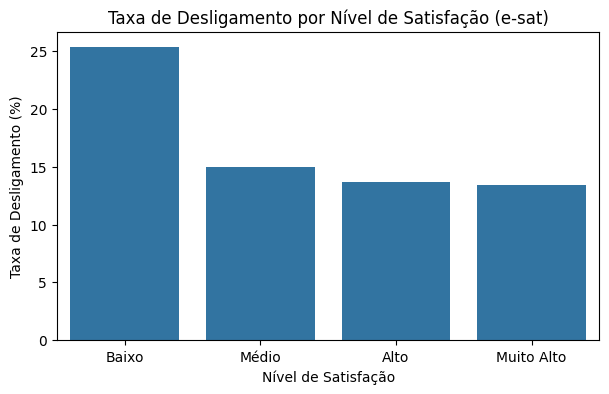

In [ ]:
# cálculo da taxa de desligamento por nível de satisfação
taxa_desligamento = (
    df
    .groupby('e-sat')['saiu_da_empresa']
    .apply(lambda x: (x == 'Sim').mean())
    .reset_index(name='taxa_desligamento')
)

taxa_desligamento['taxa_desligamento'] *= 100

# gráfico da taxa de desligamento por e-sat
plt.figure(figsize=(8,4))
order = ['Baixo', 'Médio', 'Alto', 'Muito Alto']
sns.barplot(
    data=taxa_desligamento,
    x='e-sat',
    y='taxa_desligamento',
    order=order
)
plt.title('Taxa de Desligamento por Nível de Satisfação (e-sat)')
plt.xlabel('Nível de Satisfação')
plt.ylabel('Taxa de Desligamento (%)')
plt.savefig('../assets/taxa_esat.png', bbox_inches='tight', dpi=150)
plt.show()

**Leitura do gráfico**

Os resultados indicam que o nível de satisfação dos funcionários (e-sat) exerce influência significativa sobre a saída da empresa. Funcionários com baixa satisfação apresentam taxas de desligamento consideravelmente mais altas, enquanto níveis elevados de satisfação estão associados a maior retenção. Isso sugere que ações voltadas à melhoria da experiência e satisfação dos colaboradores podem contribuir diretamente para a redução do turnover.

- Existe relação entre o nível de equilíbrio entre vida pessoal e trabalho e a probabilidade de desligamento dos funcionários?

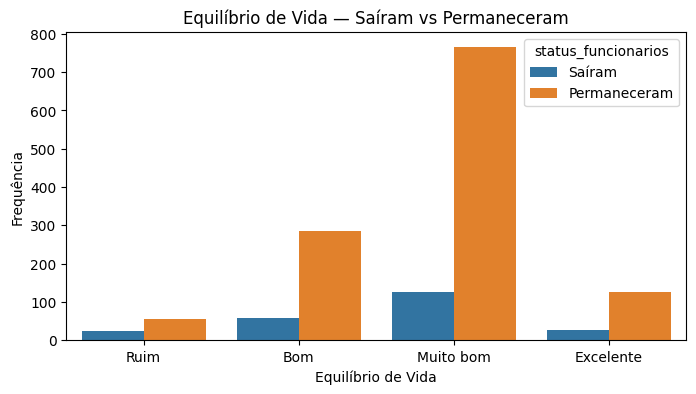

In [70]:
# gráfico saíram vs permaneceram
plt.figure(figsize=(8,4))
order=['Ruim', 'Bom', 'Muito bom', 'Excelente']
sns.countplot(
    data=df,
    x='equilibrio_de_vida',
    hue='status_funcionarios',
    order=order
)
plt.title('Equilíbrio de Vida — Saíram vs Permaneceram')
plt.xlabel('Equilíbrio de Vida')
plt.ylabel('Frequência')
plt.show()

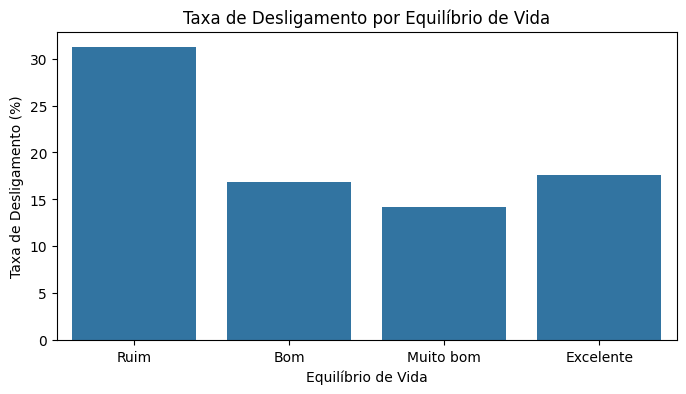

In [71]:
# cálculo da taxa de desligamento por equilíbrio de vida
taxa_desligamento = (
    df
    .groupby('equilibrio_de_vida')['saiu_da_empresa']
    .apply(lambda x: (x == 'Sim').mean())
    .reset_index(name='taxa_desligamento')
)

taxa_desligamento['taxa_desligamento'] *= 100

# gráfico da taxa de desligamento
plt.figure(figsize=(8,4))
order=['Ruim', 'Bom', 'Muito bom', 'Excelente']
sns.barplot(
    data=taxa_desligamento,
    x='equilibrio_de_vida',
    y='taxa_desligamento',
    order=order
)
plt.title('Taxa de Desligamento por Equilíbrio de Vida')
plt.xlabel('Equilíbrio de Vida')
plt.ylabel('Taxa de Desligamento (%)')
plt.show()

**Leitura do gráfico**

Apesar de o maior número absoluto de desligamentos ocorrer entre funcionários com bom equilíbrio de vida, observa-se que a taxa de desligamento é substancialmente mais alta entre aqueles que avaliam seu equilíbrio de vida como ruim, indicando um maior risco relativo de saída nesse grupo. Esse resultado sugere que a insatisfação com o equilíbrio de vida é um fator crítico associado ao desligamento, mesmo em grupos menos numerosos.

### 🔹Características Demográficas

- Idade

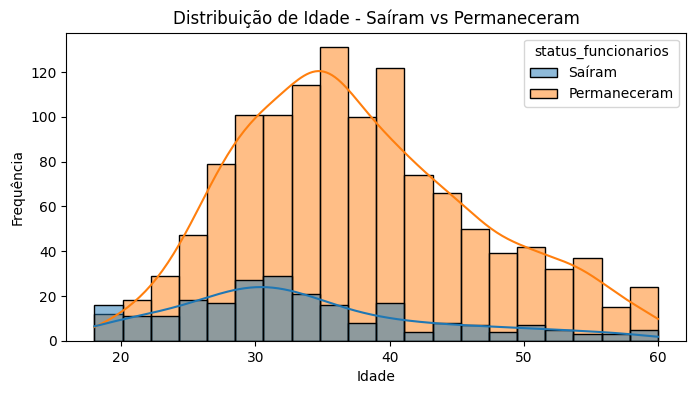

In [72]:
# gráfico do perfil etário da empresa
plt.figure(figsize=(8,4))
sns.histplot(
  data=df,
  x='idade',
  hue='status_funcionarios',
  bins=20,
  kde=True
)
plt.title('Distribuição de Idade - Saíram vs Permaneceram')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

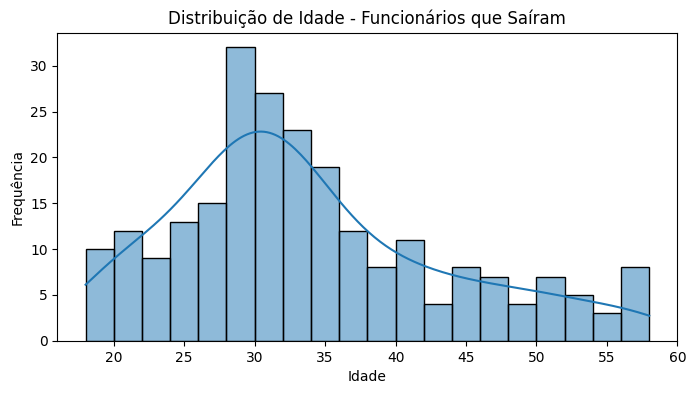

In [73]:
# gráfico da distribuição de idade dos funcionários que saíram
plt.figure(figsize=(8,4))
sns.histplot(
  df[df['saiu_da_empresa'] == 'Sim']['idade'], 
  bins=20, 
  kde=True
)
plt.title('Distribuição de Idade - Funcionários que Saíram')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

**Leitura do Gráfico**

Observa-se que a maior parte do quadro geral de funcionários concentra-se na faixa etária entre 35 e 40 anos, enquanto os desligamentos ocorrem com maior frequência entre funcionários de 30 a 35 anos. Essa diferença sugere uma leve tendência de maior rotatividade entre profissionais mais jovens.

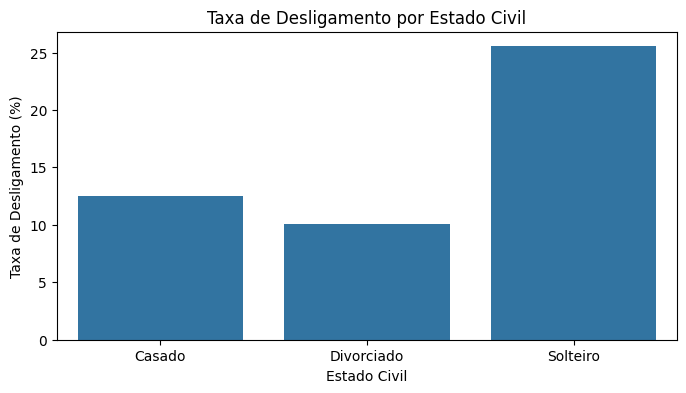

In [74]:
# estado civil
taxa_estado_civil = (
    df
    .groupby('estado_civil')['saiu_da_empresa']
    .apply(lambda x: (x == 'Sim').mean())
    .reset_index(name='taxa_desligamento')
)
taxa_estado_civil['taxa_desligamento'] *= 100

plt.figure(figsize=(8, 4))
sns.barplot(data=taxa_estado_civil, x='estado_civil', y='taxa_desligamento')
plt.title('Taxa de Desligamento por Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Taxa de Desligamento (%)')
plt.show()

**Leitura do gráfico**

Funcionários solteiros apresentam a maior taxa de desligamento (25%), mais que o
dobro da taxa observada entre divorciados (10%) e consideravelmente acima dos
casados (13%). Esse padrão pode estar associado a menor vínculo com estabilidade
financeira e maior flexibilidade para mudanças profissionais.

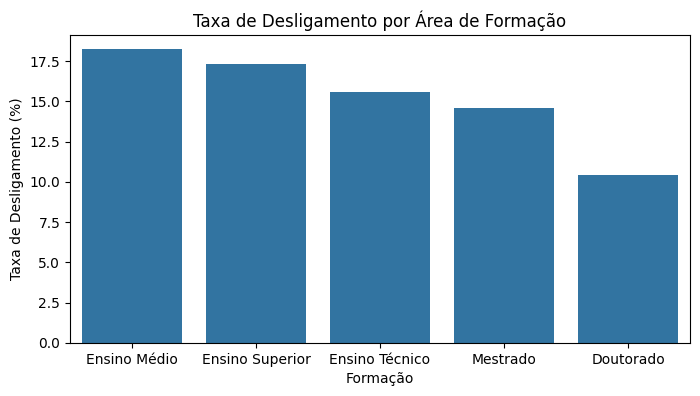

In [75]:
# formação
taxa_formacao = (
    df
    .groupby('formacao')['saiu_da_empresa']
    .apply(lambda x: (x == 'Sim').mean())
    .reset_index(name='taxa_desligamento')
)
taxa_formacao['taxa_desligamento'] *= 100
taxa_formacao = taxa_formacao.sort_values('taxa_desligamento', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=taxa_formacao, x='formacao', y='taxa_desligamento')
plt.title('Taxa de Desligamento por Área de Formação')
plt.xlabel('Formação')
plt.ylabel('Taxa de Desligamento (%)')
plt.show()

**Leitura do gráfico**

Observa-se uma tendência de redução da taxa de desligamento conforme aumenta o
nível de escolaridade: funcionários com Ensino Médio apresentam a maior taxa (18%),
enquanto aqueles com Doutorado têm a menor (10%). Isso pode refletir maior
especificidade e escassez de oportunidades equivalentes no mercado para perfis
altamente especializados, o que reduz a rotatividade.

**Conclusão**

As variáveis demográficas analisadas — idade, estado civil e formação — apresentam
associações com a rotatividade, mas devem ser interpretadas como evidências complementares. Nenhuma
delas, isoladamente, é um fator determinante para o desligamento. Esses elementos ajudam a traçar um perfil do funcionário com maior risco de desligamento quando combinados com variáveis mais
diretamente relacionadas à experiência no trabalho, como satisfação, remuneração e estágio de carreira — abordadas nas seções anteriores.